# Frontdoor Criterion

Uber와 Lyft의 공유 탑승이 팁에 미치는 인과효과를 추정하고자합니다.

- 업계에서 운전자들은 “공유 탑승을 승인하는 행동 자체가 팁 감소를 야기한다”고 믿는 경향이 있습니다.
- 그러나 공유 탑승 승인(X)은 무작위로 할당할 수 없고, 절약 성향 등 관찰할 수 없는 요인과 연관되어 내생성(endogeneity) 문제가 존재합니다.
    
    예컨대 절약적인 사람일수록 공유 탑승을 승인할 가능성이 높고, 팁을 덜 줄 가능성이 높습니다(Selection Bias).

이러한 내생성을 완화하기 위해 Front-Door Criterion (FDC) 을 적용합니다.

이를 통해 합승 승인(X) → 실제 합승 발생(M) → 팁(Y) 간의 인과경로를 분리하여 식별합니다.
- **X**: 공유 탑승 승인 여부 (`shared_request_flag`) 
- **M:** 실실제 공유 발생(`shared_match_flag`)
- **Y**: 팁(유무/금액/요금대비 비율: `tips`, `tips>0`, `tips/full_fare`)

핵심 아이디어는 앱의 매칭 알고리즘이 만들어내는 M의 외생적 변동을 활용해, “공유 탑승을 승인하는 사람의 유형(절약 성향 둥)”으로 인한 선택편향을 제거하고, 합승 자체의 효과를 분리하는 것입니다.

- **Dataset**: [NYC TLC — 2023 High Volume For-Hire Vehicle Trip Records](https://data.cityofnewyork.us/Transportation/2023-High-Volume-FHV-Trip-Data/u253-aew4/about_data) (Uber·Lyft 등 HVFHS 운행 데이터, 약 2.3억건)
- **Reference**: The Paper of How: Estimating Treatment Effects Using the Front-Door Criterion

## Identification Strategy

현실 데이터에서 FDC의 가정들이 자동으로 성립하지 않기 때문에, 조건부 외생성(conditional exogeneity) 을 확보해야 합니다.
다음 세 가지 내생성 원인을 다룹니다.

- 요금 내생성 (Fare endogeneity): 
  - 요금(Full fare)은 X와 Y 모두에 영향 → X–Y backdoor
  - 피크·혼잡 요금은 M과 Y 에도 동시 영향 → M–Y backdoor
    
    → Full fare를 1·2단계 모두에서 조건화하여 backdoor 차단

- 시간·공간 내생성 (Time–place endogeneity)
  - 특정 시간대(출퇴근·심야·이벤트)나 출발지–도착지(OD) 조합에 따라 공유 매칭 확률(M)과 팁(Y)이 동시에 변동합니다.
  
    → 시간×OD 고정효과(또는 Demeaning)로 셀 내 비교만 하게 만들어 confounding 제거

- 선택편향/유형효과 (Selection into X)
  - 절약 성향(U) 이 강한 사람일수록 공유 탑승을 승인할 확률(X=1)이 높고, 팁(Y)은 낮습니다.
    → 단순 OLS는 음(-)효과 과대
    → FDC로 X→M, M→Y를 분리 추정하고, 외생적 M 변동만으로 효과 식별

또한, one-sided noncompliance(실제 합승 M=1은 승인 X=1에서만 발생)가 대체로 성립하면, FDC 추정치는 ATT 해석에 가까워집니다.

In [133]:
%%capture
%pip install duckdb==1.0.0 polars==1.6.0 pandas==2.2.2 pyarrow==16.1.0 statsmodels==0.14.2 numpy==2.0.1

Python(18302) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [2]:
import duckdb, pandas as pd, numpy as np
import statsmodels.api as sm
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.utils import resample
import warnings

warnings.filterwarnings("ignore", message=".*variables are assumed unobserved.*", module="dowhy")

## Data Setup

큰 파일(2.3억 행)이므로 DuckDB의 lazy scan을 사용합니다.

In [3]:
# parquet_url = "https://huggingface.co/datasets/Funbucket/nyc-hvfhs-2023/resolve/main/nyc_hvfhs_2023.parquet"
parquet_url = "../data/nyc_hvfhs_2023.parquet"
con = duckdb.connect()

con.execute("INSTALL httpfs; LOAD httpfs;")

In [4]:
schema_df = con.execute(f"""
DESCRIBE SELECT * FROM read_parquet('{parquet_url}')
""").df()

sample_df = con.execute(f"""
SELECT *
FROM read_parquet('{parquet_url}')
LIMIT 5
""").df()

display(schema_df)
display(sample_df.head())

,column_name,column_type,null,key,default,extra
0,hvfhs_license_num,VARCHAR,YES,None,None,None
1,dispatching_base_num,VARCHAR,YES,None,None,None
2,request_datetime,VARCHAR,YES,None,None,None
3,pickup_datetime,TIMESTAMP WITH TIME ZONE,YES,None,None,None
4,dropoff_datetime,VARCHAR,YES,None,None,None
5,pulocationid,VARCHAR,YES,None,None,None
6,dolocationid,VARCHAR,YES,None,None,None
7,trip_miles,VARCHAR,YES,None,None,None
8,trip_time,VARCHAR,YES,None,None,None
9,base_passenger_fare,VARCHAR,YES,None,None,None


,hvfhs_license_num,dispatching_base_num,request_datetime,pickup_datetime,dropoff_datetime,pulocationid,dolocationid,trip_miles,trip_time,base_passenger_fare,...,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,originating_base_num,on_scene_datetime
0,HV0005,B03406,2022-12-31T23:57:01.000,2023-01-01 09:00:00+09:00,2023-01-01T00:36:41.000,233,48,1.946,2201,15.11,...,0.0,0.0,21.8,N,N,N,N,False,None,None
1,HV0003,B03404,2022-12-31T23:57:11.000,2023-01-01 09:00:00+09:00,2023-01-01T00:06:59.000,247,167,1.66,419,10.54,...,0.0,0.0,6.48,N,N,None,N,False,B03404,2022-12-31T23:59:51.000
2,HV0005,B03406,2022-12-31T23:54:24.000,2023-01-01 09:00:00+09:00,2023-01-01T00:05:47.000,228,227,1.327,347,7.76,...,0.0,1.0,5.47,N,N,N,N,False,None,None
3,HV0005,B03406,2022-12-31T23:57:47.000,2023-01-01 09:00:00+09:00,2023-01-01T00:54:20.000,152,149,23.633,3260,58.04,...,0.0,14.16,64.29,N,N,N,N,True,None,None
4,HV0003,B03404,2022-12-31T23:55:54.000,2023-01-01 09:00:01+09:00,2023-01-01T00:09:23.000,157,160,2.2,562,10.02,...,0.0,0.0,8.27,N,N,None,N,False,B03404,2022-12-31T23:59:33.000


read_parquet를 여러 단계에서 중복 호출하지 않도록 원본 스캔을 뷰로 고정합니다.

In [5]:
# lazy anchor
con.execute(f"""
CREATE OR REPLACE VIEW hvfhs AS
SELECT
  hvfhs_license_num,
  dispatching_base_num,
  request_datetime,             
  pickup_datetime,
  dropoff_datetime,             
  pulocationid, dolocationid,   
  trip_miles, trip_time,        
  base_passenger_fare, tolls, bcf, sales_tax,
  congestion_surcharge, airport_fee, tips, driver_pay,
  shared_request_flag, shared_match_flag,                
  access_a_ride_flag, wav_request_flag,                  
  wav_match_flag,                                       
  originating_base_num, on_scene_datetime
FROM read_parquet('{parquet_url}');
""")

### 타입 정규화

In [6]:
con.execute("""
CREATE OR REPLACE VIEW hvfhs_typed AS
WITH t AS (
  SELECT
    h.*,

    TRY_CAST(base_passenger_fare AS DECIMAL(18,2))    AS base_passenger_fare_c,
    TRY_CAST(tolls               AS DECIMAL(18,2))    AS tolls_c,
    TRY_CAST(bcf                 AS DECIMAL(18,2))    AS bcf_c,
    TRY_CAST(sales_tax           AS DECIMAL(18,2))    AS sales_tax_c,
    TRY_CAST(congestion_surcharge AS DECIMAL(18,2))   AS congestion_surcharge_c,
    TRY_CAST(airport_fee         AS DECIMAL(18,2))    AS airport_fee_c,
    TRY_CAST(tips                AS DECIMAL(18,2))    AS tips_c,
    TRY_CAST(driver_pay          AS DECIMAL(18,2))    AS driver_pay_c,

    TRY_CAST(trip_miles          AS DOUBLE)           AS trip_miles_d,
    TRY_CAST(trip_time           AS DOUBLE)           AS trip_time_d,

    TRY_CAST(pulocationid AS INTEGER) AS pulocationid_i,
    TRY_CAST(dolocationid AS INTEGER) AS dolocationid_i,

    CASE WHEN LOWER(TRIM(COALESCE(shared_request_flag,''))) IN ('y','yes','true','1') THEN 1 ELSE 0 END AS X_authorized,
    CASE WHEN LOWER(TRIM(COALESCE(shared_match_flag,'')))   IN ('y','yes','true','1') THEN 1 ELSE 0 END AS M_shared,

    TRY_STRPTIME(request_datetime,  '%Y-%m-%d %H:%M:%S') AS request_ts,
    TRY_STRPTIME(dropoff_datetime,  '%Y-%m-%d %H:%M:%S') AS dropoff_ts,
    TRY_STRPTIME(on_scene_datetime, '%Y-%m-%d %H:%M:%S') AS on_scene_ts
  FROM hvfhs h
)
SELECT * FROM t;

""")


### 파생변수

- Full fare = base + tolls + sales_tax + congestion_surcharge + airport_fee + bcf
- 결과변수:
  - **팁 유무**: Y_tip_dummy
  - **팁 금액**: Y_tip_amount 
  - **팁/요금 비율**: Y_tip_share 
- **2시간 슬롯**: 0..11 (하루 12개 셀)
- **품질 필터**: 음수/결측/이상치 제거

In [7]:
con.execute("""
CREATE OR REPLACE VIEW hvfhs_prep AS
WITH base AS (
  SELECT
    *,
    
    COALESCE(base_passenger_fare_c,  0)
  + COALESCE(tolls_c,                0)
  + COALESCE(sales_tax_c,            0)
  + COALESCE(congestion_surcharge_c, 0)
  + COALESCE(airport_fee_c,          0)
  + COALESCE(bcf_c,                  0) AS full_fare_c,

    CAST(
      FLOOR(EXTRACT(HOUR FROM (pickup_datetime AT TIME ZONE 'America/New_York')) / 2.0)
      AS INTEGER
    ) AS time_slot_2h
  FROM hvfhs_typed
),
prep AS (
  SELECT
    *,
    
    CASE WHEN COALESCE(tips_c, 0) > 0 THEN 1 ELSE 0 END AS Y_tip_dummy,
    COALESCE(tips_c, 0)                                 AS Y_tip_amount_c,
    CASE 
      WHEN full_fare_c > 0 THEN COALESCE(tips_c, 0) / full_fare_c 
      ELSE NULL 
    END AS Y_tip_share_c
  FROM base
  WHERE
    COALESCE(trip_time_d,  0.0) >= 0.0
    AND COALESCE(trip_miles_d, 0.0) >= 0.0
    AND pickup_datetime IS NOT NULL
    AND pulocationid IS NOT NULL
    AND dolocationid IS NOT NULL
)
SELECT
  
  *,
  CAST(full_fare_c      AS DOUBLE) AS full_fare,
  CAST(Y_tip_amount_c   AS DOUBLE) AS Y_tip_amount,
  CAST(Y_tip_share_c    AS DOUBLE) AS Y_tip_share
FROM prep
WHERE
  full_fare_c >= 3.00
  AND (Y_tip_share_c IS NULL OR Y_tip_share_c BETWEEN 0 AND 5.00);

""")

con.execute("SELECT COUNT(*) AS n FROM hvfhs_prep").df().head()


,n
0,232411474


### One-Sided Noncompliance 점검

- M=1이면 거의 항상 X=1인지 여부 확인(낮은 위반율이면 양호)

- 위반 행을 제외한 재추정으로 민감도 체크 가능

In [8]:
con.execute("""
SELECT
  SUM(CASE WHEN M_shared=1 AND X_authorized=0 THEN 1 ELSE 0 END) AS violations,
  SUM(CASE WHEN M_shared=1 THEN 1 ELSE 0 END)                     AS all_shared,
  1.0 * SUM(CASE WHEN M_shared=1 AND X_authorized=0 THEN 1 ELSE 0 END)
      / NULLIF(SUM(CASE WHEN M_shared=1 THEN 1 ELSE 0 END),0)     AS violation_rate
FROM hvfhs_prep
""").fetchdf()


,violations,all_shared,violation_rate
0,13606.0,2062149.0,0.006598


### 시간×공간 고정효과: demeaning

- 수많은 더미 대신 셀 평균을 빼는 방법을 사용합니다.
- **셀 정의**: (pulocationid, dolocationid, time_slot_2h)

In [9]:
SAMPLE_RATE = 0.3

con.execute(f"""
CREATE OR REPLACE TEMP VIEW sample AS
SELECT *
FROM hvfhs_prep
USING SAMPLE {int(SAMPLE_RATE*100)} PERCENT (bernoulli)
""")

# 셀 평균(OD×2h)
con.execute("""
CREATE OR REPLACE TEMP VIEW cell_means AS
SELECT
  pulocationid_i AS pu,
  dolocationid_i AS do,
  time_slot_2h   AS ts,
  AVG(X_authorized) AS X_bar,
  AVG(M_shared)     AS M_bar,
  AVG(full_fare)    AS F_bar,
  AVG(Y_tip_dummy)  AS Yd_bar,
  AVG(Y_tip_amount) AS Ya_bar,
  AVG(Y_tip_share)  AS Ys_bar,
  COUNT(*)          AS n_cell
FROM sample
GROUP BY 1,2,3
""")

# demeaning
con.execute("""
CREATE OR REPLACE TEMP VIEW demeaned AS
SELECT
  s.pulocationid_i AS pu,
  s.dolocationid_i AS do,
  s.time_slot_2h   AS ts,

  (s.X_authorized - m.X_bar) AS X_tilde,
  (s.M_shared     - m.M_bar) AS M_tilde,
  (s.full_fare    - m.F_bar) AS F_tilde,

  (s.Y_tip_dummy  - m.Yd_bar) AS Yd_tilde,
  (s.Y_tip_amount - m.Ya_bar) AS Ya_tilde,
  (s.Y_tip_share  - m.Ys_bar) AS Ys_tilde
FROM sample s
JOIN cell_means m
  ON s.pulocationid_i = m.pu
 AND s.dolocationid_i = m.do
 AND s.time_slot_2h   = m.ts
WHERE s.Y_tip_share IS NOT NULL
""")

df = con.execute("SELECT * FROM demeaned").fetchdf()
df.info(show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69678806 entries, 0 to 69678805
Data columns (total 9 columns):
 #   Column    Non-Null Count     Dtype  
---  ------    --------------     -----  
 0   pu        69678806 non-null  int32  
 1   do        69678806 non-null  int32  
 2   ts        69678806 non-null  int32  
 3   X_tilde   69678806 non-null  float64
 4   M_tilde   69678806 non-null  float64
 5   F_tilde   69678806 non-null  float64
 6   Yd_tilde  69678806 non-null  float64
 7   Ya_tilde  69678806 non-null  float64
 8   Ys_tilde  69678806 non-null  float64
dtypes: float64(6), int32(3)
memory usage: 3.9 GB


## Model

- U(관찰불가)는 데이터에 없으므로 hidden 처리
- 실제 FE는 demeaning으로 흡수했으므로 DAG에서는 생략

In [10]:
from dowhy import CausalModel

/Users/hc.cho/Projects/awesome-causal-inference-python/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
gml_frontdoor = """
graph [
  directed 1

  node [ id "X" label "X" ]  
  node [ id "M" label "M" ]  
  node [ id "Y" label "Y" ]  
  node [ id "U" label "U" observed 0 ] 

  edge [ source "X" target "M" ]
  edge [ source "M" target "Y" ]

  edge [ source "U" target "X" ]
  edge [ source "U" target "Y" ]
]
"""

In [12]:
use_ident = df[['X_tilde','M_tilde','Ys_tilde']].dropna().copy()
use_ident = use_ident.rename(columns={'X_tilde':'X','M_tilde':'M','Ys_tilde':'Y'})

cm_fd = CausalModel(
    data=use_ident,
    treatment='X',
    outcome='Y',
    graph=gml_frontdoor
)
estimand_fd = cm_fd.identify_effect()
estimand_fd

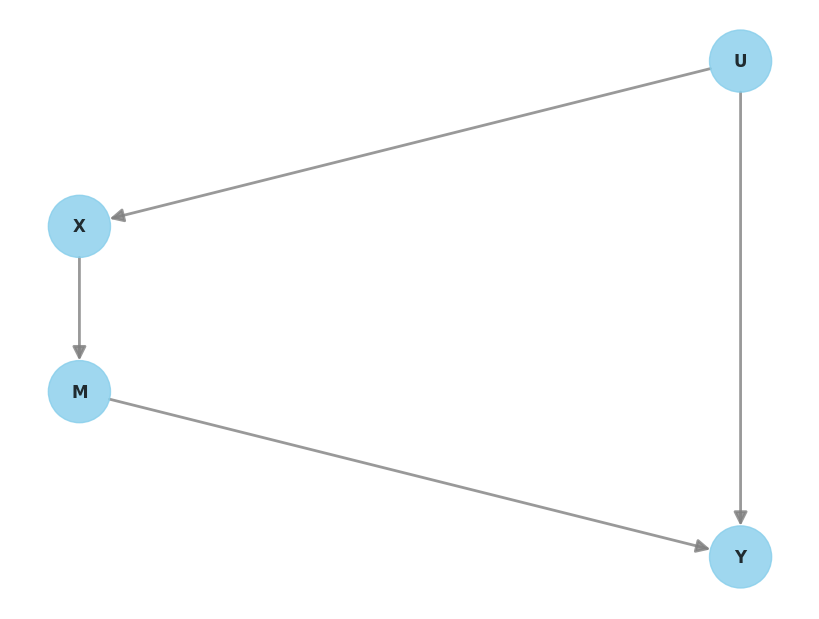

In [13]:
cm_fd.view_model(layout="dot")

## Estimate — Parametric

### FDC 가정

1. X의 Y에 대한 효과는 전부 M을 경유한다.  
2. X–M backdoor 없음 (Fare·시간/공간을 통제해 충족)  
3. M–Y backdoor 없음 (Fare·시간/공간 및 X를 조건화해 충족) 
    
    → $Y(m) \perp M \mid X,\ \text{Fare},\ \text{FE}$

### FDC first stage

$$
M = \kappa + \gamma X + \tau F + FE + \omega
$$
- FDC 가정 (2)을 충족하기 위해 X–M 사이의 backdoor는 Fare, 시간·공간 FE로 차단합니다.  
- demeaning으로 FE 흡수 → 여기서는 $\tilde M$ ~ $\tilde X$ + $\tilde F$

In [14]:
X1 = sm.add_constant(df[['X_tilde','F_tilde']])
y1 = df['M_tilde']

model1 = sm.OLS(y1, X1).fit(cov_type='HC1')
gamma_hat = model1.params['X_tilde']
se_gamma  = model1.bse['X_tilde']
model1.summary().tables[1]


,coef,std err,z,P>|z|,[0.025,0.975]
const,8.089e-06,9.23e-06,0.877,0.381,-1e-05,2.62e-05
X_tilde,0.3263,0.000,972.024,0.000,0.326,0.327
F_tilde,-0.0002,6.1e-07,-264.459,0.000,-0.000,-0.000


### FDC second stage

$$
Y = \lambda + \delta M + \phi X + \pi F + FE + \nu
$$

- FDC 가정 (3)을 충족하기 위해 M–Y 사이의 backdoor는 Fare, 시간·공간 FE로 차단합니다. 
- demeaning으로 FE 흡수 → $\tilde Y$ ~ $\tilde M$ + $\tilde X$ + $\tilde F$

In [15]:
def second_stage(outcome_col):
    cols = ['M_tilde','X_tilde','F_tilde', outcome_col]
    d2 = df[cols].dropna()
    X2 = sm.add_constant(d2[['M_tilde','X_tilde','F_tilde']])
    y2 = d2[outcome_col]
    fit = sm.OLS(y2, X2).fit(cov_type='HC1')
    delta = fit.params['M_tilde']
    se    = fit.bse['M_tilde']
    return fit, delta, se

fit_dummy,  delta_d, se_d = second_stage('Yd_tilde')  # 팁 유무
fit_amount, delta_a, se_a = second_stage('Ya_tilde')  # 팁 금액
fit_share,  delta_s, se_s = second_stage('Ys_tilde')  # 팁 비율

fit_dummy.summary().tables[1]


,coef,std err,z,P>|z|,[0.025,0.975]
const,9.992e-05,4.61e-05,2.165,0.030,9.47e-06,0.000
M_tilde,0.0096,0.000,20.256,0.000,0.009,0.011
X_tilde,-0.0716,0.000,-272.941,0.000,-0.072,-0.071
F_tilde,0.0008,4.51e-06,186.576,0.000,0.001,0.001


### Front Door Effect

- 총 효과는 1단계와 2단계 추정치의 곱으로 계산합니다.
  $Effect = \gamma \times \delta$
- 이론적으로는 ATE 형태지만, one-sided noncompliance 상황에서는 ATT, 즉 공유를 승인한 사람들(X=1) 내에서의 평균 효과로 해석됩니다. 
- 표준오차는 델타법으로 근사합니다.(보수적으로 Cov=0 가정)

    $$
    \operatorname{Var}(\gamma \delta) \approx 
    \delta^2 \operatorname{Var}(\gamma) +
    \gamma^2 \operatorname{Var}(\delta) +
    2\gamma\delta\,\operatorname{Cov}(\gamma, \delta)
    $$

In [16]:
def product_and_se(gamma, se_g, delta, se_d, cov_gd=0.0):
    var_prod = (delta**2)*(se_g**2) + (gamma**2)*(se_d**2) + 2*gamma*delta*cov_gd
    return gamma*delta, np.sqrt(var_prod)

def ci95(est, se):
    return est - 1.96*se, est + 1.96*se

ate_dummy,  se_ate_dummy  = product_and_se(gamma_hat, se_gamma, delta_d, se_d, cov_gd=0.0)
ate_amount, se_ate_amount = product_and_se(gamma_hat, se_gamma, delta_a, se_a, cov_gd=0.0)
ate_share,  se_ate_share  = product_and_se(gamma_hat, se_gamma, delta_s, se_s, cov_gd=0.0)

ci_dummy   = ci95(ate_dummy,  se_ate_dummy)
ci_amount  = ci95(ate_amount, se_ate_amount)
ci_share   = ci95(ate_share,  se_ate_share)

pd.DataFrame({
  'Outcome': ['Tip Dummy (Pr[tips>0])','Tip Amount ($)','Tip Share (tips/full_fare)'],
  'gamma_hat (X→M)': [gamma_hat]*3,
  'delta_hat (M→Y|X,F,FE)': [delta_d, delta_a, delta_s],
  'Front-Door ATE = γ×δ': [ate_dummy, ate_amount, ate_share],
  'SE (Delta method)': [se_ate_dummy, se_ate_amount, se_ate_share],
  '95% CI (lower, upper)': [ci_dummy, ci_amount, ci_share]
})


,Outcome,gamma_hat (X→M),"delta_hat (M→Y|X,F,FE)",Front-Door ATE = γ×δ,SE (Delta method),"95% CI (lower, upper)"
0,Tip Dummy (Pr[tips>0]),0.326298,0.009624,0.003140,0.000155,"(0.0028363959291469554, 0.003444241561415614)"
1,Tip Amount ($),0.326298,0.096123,0.031365,0.000823,"(0.02975075442226394, 0.03297868294072024)"
2,Tip Share (tips/full_fare),0.326298,0.003746,0.001222,0.000030,"(0.0011641079274583937, 0.0012804900349996286)"


## Estimate — Nonparametric (Two-Stage ML + APD)

$$
\mathrm{FD}
=
\underbrace{\mathbb{E}\!\left[\frac{\partial\,\mathbb{E}[M\mid X,F]}{\partial X}\right]}_{\gamma}
\times
\underbrace{\mathbb{E}\!\left[\frac{\partial\,\mathbb{E}[Y\mid M,X,F]}{\partial M}\right]}_{\delta}
$$

**핵심 아이디어**

- **1단계 (X→M):**  
  ML로 $\widehat{m}(x,f)\approx\mathbb{E}[M\!\mid\!X,F]$ 를 학습하고, $X$에 대한 **평균 부분미분(APD)** 으로 $\widehat\gamma$ 추정합니다.

- **2단계 (M→Y):**  
  ML로 $\widehat{y}(m,x,f)\approx\mathbb{E}[Y\!\mid\!M,X,F]$ 를 학습하고, $M$에 대한 **APD** 로 $\widehat\delta$ 추정합니다.

- **최종 효과:**  
  $$
  \widehat{\mathrm{FD}}
  = \widehat\gamma \times \widehat\delta
  $$

In [17]:
RANDOM_SEED = 123
np.random.seed(RANDOM_SEED)

def apd_central(model, X, col_idx, eps, *, proba=False):
    """
    평균 부분미분(APD): (f(x+eps) - f(x-eps)) / (2*eps)의 표본 평균.
    - proba=True: classifier의 predict_proba(., 1) 사용
    """
    Xp = X.copy(); Xm = X.copy()
    Xp[:, col_idx] = Xp[:, col_idx] + eps
    Xm[:, col_idx] = Xm[:, col_idx] - eps
    if proba:
        y0 = model.predict_proba(Xp)[:, 1]
        y1 = model.predict_proba(Xm)[:, 1]
    else:
        y0 = model.predict(Xp)
        y1 = model.predict(Xm)
    return float(np.mean((y0 - y1) / (2.0 * eps)))

- 메모리/시간 절약을 위해 최대 $N_{\max}$ 표본만 사용합니다.

In [18]:
N_MAX = 3_000_000
_needed = ['X_tilde','M_tilde','F_tilde','Yd_tilde','Ya_tilde','Ys_tilde']
d = df[_needed].dropna(subset=['X_tilde','M_tilde','F_tilde']).copy()
if N_MAX is not None and len(d) > N_MAX:
    d = d.sample(n=N_MAX, random_state=RANDOM_SEED)

d = d.rename(columns={'X_tilde':'X','M_tilde':'M'})
EPS_X = 0.01
EPS_M = 0.01

### Stage 1: $\widehat{m}(x,f)$

In [19]:
X1 = d[['X','F_tilde']].to_numpy()
y1 = d['M'].to_numpy()

m_model = GradientBoostingRegressor(random_state=RANDOM_SEED)
m_model.fit(X1, y1)

gamma_hat = apd_central(m_model, X1, col_idx=0, eps=EPS_X, proba=False)
print(f"gamma_hat = {gamma_hat:.6f}")

gamma_hat = 0.272132


### Stage 2(팁 유무)


- **Binary \(Y\)**: 확률의 APD  
- **Continuous \(Y\)**: 조건부 기대값의 APD

In [20]:
# Y = Tip Dummy (binary)
d_bin = d.dropna(subset=['Yd_tilde']).copy()
X2_d  = d_bin[['M','X','F_tilde']].to_numpy()
y2_d  = d_bin['Yd_tilde'].to_numpy().astype(int)

clf = GradientBoostingClassifier(random_state=RANDOM_SEED)
clf.fit(X2_d, y2_d)

delta_hat_d = apd_central(clf, X2_d, col_idx=0, eps=EPS_M, proba=True)
fd_d = gamma_hat * delta_hat_d
print(f"[Tip Dummy] delta={delta_hat_d:.6f}  FD={fd_d:.6f}")

[Tip Dummy] delta=-0.035799  FD=-0.009742


### Stage 2(팁 금액)


In [21]:
# Y = Tip Amount (continuous)
d_amt = d.dropna(subset=['Ya_tilde']).copy()
X2_a  = d_amt[['M','X','F_tilde']].to_numpy()
y2_a  = d_amt['Ya_tilde'].to_numpy()

reg_a = GradientBoostingRegressor(random_state=RANDOM_SEED)
reg_a.fit(X2_a, y2_a)

delta_hat_a = apd_central(reg_a, X2_a, col_idx=0, eps=EPS_M, proba=False)
fd_a = gamma_hat * delta_hat_a
print(f"[Tip Amount] delta={delta_hat_a:.6f}  FD={fd_a:.6f}")

[Tip Amount] delta=0.305067  FD=0.083018


### Stage 2(팁 비율)

In [22]:
# Y = Tip Share (continuous)
d_shr = d.dropna(subset=['Ys_tilde']).copy()
X2_s  = d_shr[['M','X','F_tilde']].to_numpy()
y2_s  = d_shr['Ys_tilde'].to_numpy()

reg_s = GradientBoostingRegressor(random_state=RANDOM_SEED)
reg_s.fit(X2_s, y2_s)

delta_hat_s = apd_central(reg_s, X2_s, col_idx=0, eps=EPS_M, proba=False)
fd_s = gamma_hat * delta_hat_s
print(f"[Tip Share]  delta={delta_hat_s:.6f}  FD={fd_s:.6f}")

[Tip Share]  delta=0.010891  FD=0.002964


### 요약

In [23]:
summary = pd.DataFrame({
    "Outcome": ["Tip Dummy (Pr[tips>0])", "Tip Amount ($)", "Tip Share (tips/full_fare)"],
    "gamma (dE[M|X,F]/dX)": [gamma_hat, gamma_hat, gamma_hat],
    "delta (dE[Y|M,X,F]/dM)": [delta_hat_d, delta_hat_a, delta_hat_s],
    "FD = gamma × delta": [fd_d, fd_a, fd_s],
})
summary


,Outcome,"gamma (dE[M|X,F]/dX)","delta (dE[Y|M,X,F]/dM)",FD = gamma × delta
0,Tip Dummy (Pr[tips>0]),0.272132,-0.035799,-0.009742
1,Tip Amount ($),0.272132,0.305067,0.083018
2,Tip Share (tips/full_fare),0.272132,0.010891,0.002964


## Naive OLS와 비교 (선택편향의 크기 보기)

- Naive: $\tilde Y \sim \tilde X + \tilde F$ (M 없이) → 선택편향 포함
- Naive의 음(-) 추정과 달리, FDC 추정치는 작지만 양(+)의 효과로 유의하게 추정됨

    →  “공유 승인자들이 팁이 낮다”는 관찰된 관계의 대부분은 **선택편향**에서 비롯되며, **공유 자체의 인과효과는 거의 미미합니다.**

In [24]:
def naive(outcome_col):
    cols = ['X_tilde','F_tilde', outcome_col]
    dn = df[cols].dropna()
    Xn = sm.add_constant(dn[['X_tilde','F_tilde']])
    yn = dn[outcome_col]
    fit = sm.OLS(yn, Xn).fit(cov_type='HC1')
    b   = fit.params['X_tilde']
    se  = fit.bse['X_tilde']
    return fit, b, se

n_fit_d, nb_d, nse_d = naive('Yd_tilde')
n_fit_a, nb_a, nse_a = naive('Ya_tilde')
n_fit_s, nb_s, nse_s = naive('Ys_tilde')

pd.DataFrame({
  'Outcome': ['Tip Dummy','Tip Amount','Tip Share'],
  'Naive beta (X→Y)': [nb_d, nb_a, nb_s],
  'Naive SE': [nse_d, nse_a, nse_s],
  'FDC ATE (γ×δ)': [ate_dummy, ate_amount, ate_share],
  'FDC SE (Delta)': [se_ate_dummy, se_ate_amount, se_ate_share]
})


,Outcome,Naive beta (X→Y),Naive SE,FDC ATE (γ×δ),FDC SE (Delta)
0,Tip Dummy,-0.068459,0.000226,0.003140,0.000155
1,Tip Amount,-0.203539,0.001498,0.031365,0.000823
2,Tip Share,-0.013674,0.000044,0.001222,0.000030
